# Data Exploration

In [16]:
# Reading in data
import pandas as pd
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parent
pbp = pd.read_parquet(ROOT / "data/interim/pbp_clean.parquet")

# First 5 rows of dataset
pbp.head()

,game_id,season,down,ydstogo,yardline_100,half_seconds_remaining,game_seconds_remaining,score_differential,play_type,shotgun,no_huddle,posteam,defteam,yards_gained
0,2024_01_ARI_BUF,2024,1,10,70.0,1800.0,3600.0,0.0,run,0.0,0.0,ARI,BUF,3.0
1,2024_01_ARI_BUF,2024,2,7,67.0,1767.0,3567.0,0.0,pass,0.0,0.0,ARI,BUF,22.0
2,2024_01_ARI_BUF,2024,1,10,45.0,1723.0,3523.0,0.0,pass,1.0,0.0,ARI,BUF,9.0
3,2024_01_ARI_BUF,2024,2,1,36.0,1682.0,3482.0,0.0,run,0.0,0.0,ARI,BUF,2.0
4,2024_01_ARI_BUF,2024,1,10,34.0,1646.0,3446.0,0.0,run,1.0,0.0,ARI,BUF,2.0


In [ ]:
# Column names, length, null values & data types
pbp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279917 entries, 0 to 279916
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   game_id                 279917 non-null  object 
 1   season                  279917 non-null  int64  
 2   down                    279917 non-null  Int64  
 3   ydstogo                 279917 non-null  Int64  
 4   yardline_100            279917 non-null  float32
 5   half_seconds_remaining  279917 non-null  float32
 6   game_seconds_remaining  279917 non-null  float32
 7   score_differential      279917 non-null  float32
 8   play_type               279917 non-null  object 
 9   shotgun                 279917 non-null  float32
 10  no_huddle               279917 non-null  float32
 11  posteam                 279917 non-null  object 
 12  defteam                 279917 non-null  object 
 13  yards_gained            279917 non-null  float32
dtypes: Int64(2), float32

## Target Variable Expoloration

In [ ]:
# Describing target variable
pbp["yards_gained"].describe()

count    279917.000000
mean          5.448522
std           8.616379
min         -34.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          99.000000
Name: yards_gained, dtype: float64

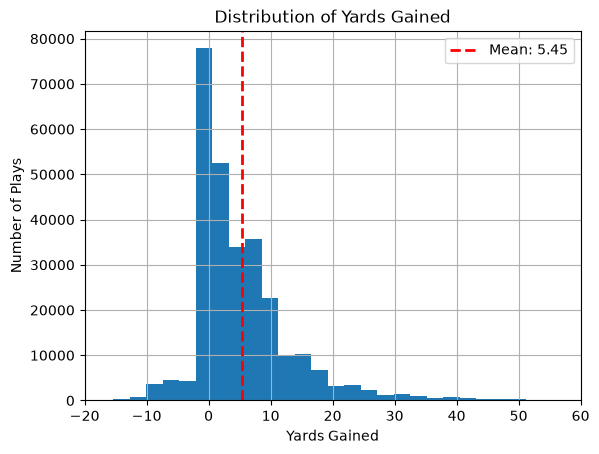

In [31]:
# Visualizing distribution of yards gained per play
import matplotlib.pyplot as plt
pbp["yards_gained"].hist(bins=50)

plt.xlabel("Yards Gained")
plt.ylabel("Number of Plays")
plt.title("Distribution of Yards Gained")
plt.xlim(-20, 60)

# Highlighting excpected yards per play
exp_yards = pbp["yards_gained"].mean()
plt.axvline(exp_yards, color="red", linestyle="dashed", 
            linewidth=2, label=f"Mean: {exp_yards:.2f}")

plt.legend()
plt.show()